# §45J Derating Analysis: Can Running Below Full Capacity Capture the Full $0.018/kWh Credit?

**The question:** §45J's nominal production tax credit rate is $0.018/kWh ("1.8 cents," "the whole 18c"), but earlier analysis found the *effective* rate is capped well below that (~$0.0143/kWh at ~100% capacity factor for a 1200 MW unit), because §45J(c)(1) caps the **annual dollar credit** at $125M per 1000 MW of allocated (rated) capacity -- not per kWh produced. The cap is based on rated capacity, which doesn't change if the plant runs below full output. So: if the plant deliberately produces less energy per year (a lower capacity factor, i.e. "derating"), does the annual credit stop being cap-limited, letting it collect the full nominal $0.018/kWh on every kWh it does produce? And if so, does that actually help combined LCOE, or does producing less energy (while CapEx stays fixed) hurt LCOE more than the better credit rate helps?

**The math:** the annual §45J cap binds whenever
$$
0.018 \times (\text{capacity}_{kW} \times 8760 \times CF) > 125{,}000{,}000 \times \frac{\text{capacity}_{MW}}{1000},
$$
which simplifies (capacity cancels out) to a **capacity-factor threshold independent of plant size**:
$$
CF^* = \frac{125}{0.018 \times 8760} \approx 0.7928 \ \ (\text{i.e. ~79.3\%}).
$$
Below CF≈79.3%, the cap does not bind and the plant collects the full nominal $0.018/kWh rate on its (reduced) production. Above that, the credit is capped at a fixed dollar amount regardless of how much more the plant produces.

This notebook sweeps capacity factor from 50% to 100% for a 1200 MW unit, computes the resulting effective §45J rate and combined LCOE at each point using the same monkeypatched PTC mechanism (`pf.add_incentive`) used in `lcoe_npv_itc_ptc_analysis.ipynb`, and checks whether the CF≈79.3% threshold is actually a good operating point for LCOE -- or just for maximizing the per-kWh credit rate in isolation.

In [1]:
import sys
sys.path.insert(0, "/Users/svijaysh/NPP+DCfork/H2Integrate")

import copy
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from h2integrate.core.h2integrate_model import H2IntegrateModel
from h2integrate.core.file_utils import get_path
from h2integrate.finances.profast_base import ProFastBase

EXAMPLE_DIR = get_path("examples/32_nuclear_DC_case_1")

with open(EXAMPLE_DIR / "plant_config.yaml") as f:
    base_plant_config = yaml.safe_load(f)


def make_h2i(plant_config_dict):
    config = {
        "name": "nuclear_datacenter_config",
        "system_summary": "Nuclear plant powering a data center",
        "driver_config": str(EXAMPLE_DIR / "driver_config.yaml"),
        "technology_config": str(EXAMPLE_DIR / "tech_config.yaml"),
        "plant_config": plant_config_dict,
    }
    model = H2IntegrateModel(config)
    model.setup()
    return model


def run_derated(model, capacity_kw, capacity_factor):
    """Run nuclear at a constant output of capacity_kw * capacity_factor for
    every hour of the year -- a deliberately derated, constant dispatch
    (not a realistic outage profile, just the simplest way to produce a
    specific annual capacity factor for this analysis)."""
    model.prob.set_val("nuclear.system_capacity", capacity_kw, units="kW")
    model.prob.set_val("grid.interconnection_size", capacity_kw, units="kW")
    # nuclear_poi: cost-only interconnection technology (see tech_config.yaml)
    # included in the LCOE finance subgroup so nuclear's own POI CapEx/OpEx
    # isn't silently dropped -- keep it sized to match nuclear's capacity.
    model.prob.set_val("nuclear_poi.interconnection_size", capacity_kw, units="kW")
    derated_kw = capacity_kw * capacity_factor
    model.prob.set_val(
        "nuclear.electricity_command_value", np.full(8760, derated_kw), units="kW"
    )
    model.prob.set_val(
        "grid.electricity_command_value", np.full(8760, 500_000), units="kW"
    )
    model.run()


def set_itc(plant_config_dict, value_usd):
    """Apply an ITC value to the LCOE finance-group config (0 here -- this
    notebook isolates the §45J PTC effect, not ITC)."""
    pc = copy.deepcopy(plant_config_dict)
    pc["finance_parameters"]["finance_groups"]["model_inputs"]["params"][
        "one_time_cap_inct"
    ]["value"] = float(value_usd)
    return pc


def shortify(breakdown):
    out = {}
    for k, v in breakdown.items():
        short = re.sub(r"\s*\([^)]*\)\s*$", "", k.replace("LCOE: ", "")).strip()
        out[short] = v * 1000  # $/kWh -> $/MWh
    for cat in ("CapEx", "OpEx", "Feedstock"):
        poi_key = f"nuclear_poi {cat}"
        if poi_key in out:
            out[f"nuclear {cat}"] = out.get(f"nuclear {cat}", 0.0) + out.pop(poi_key)
    return out


# -- Monkeypatch: let ProFAST apply a per-kWh production tax credit ------------
# Same mechanism as lcoe_npv_itc_ptc_analysis.ipynb: H2Integrate has no config
# path for ProFAST's `add_incentive`, so it's patched in here.
if not hasattr(ProFastBase, "_orig_populate_profast"):
    ProFastBase._orig_populate_profast = ProFastBase.populate_profast

    def _populate_profast_with_ptc(self, inputs):
        pf = ProFastBase._orig_populate_profast(self, inputs)
        ptc = getattr(self, "_ptc_config", None)
        if ptc is not None:
            pf.add_incentive(
                name="PTC_nuclear",
                value=ptc["value_per_kwh"],
                decay=0.0,
                sunset_years=ptc["sunset_years"],
                tax_credit=True,
            )
        return pf

    ProFastBase.populate_profast = _populate_profast_with_ptc


def get_lco_component(model):
    for subsys in model.model.system_iter(include_self=True, recurse=True):
        if type(subsys).__name__ == "ProFastLCO":
            return subsys
    raise RuntimeError("ProFastLCO component not found in model tree")


def get_45j_config(capacity_kw, capacity_factor=1.0, sunset_years=8):
    """§45J(c)(1): the annual credit is capped at $125,000,000 per 1,000 MW of
    allocated (rated) national megawatt capacity -- NOT per kWh produced, so
    the cap doesn't shrink if the plant is derated. Returns the properly
    capped effective rate for this capacity and capacity factor."""
    capacity_mw = capacity_kw / 1000
    annual_cap_usd = 125_000_000 * (capacity_mw / 1000)
    annual_production_kwh = capacity_kw * 8760 * capacity_factor
    nominal_rate = 0.018
    capped_rate = annual_cap_usd / annual_production_kwh
    return {"value_per_kwh": min(nominal_rate, capped_rate), "sunset_years": sunset_years}


## Sweep: Capacity Factor 50%-100%, Effective §45J Rate and Combined LCOE

In [2]:
CAPACITY_MW = 1200  # single AP1000 unit
CAPACITY_KW = CAPACITY_MW * 1000
CF_THRESHOLD = 125 / (0.018 * 8760)  # ~0.7928, cap-binding threshold (size-independent)

capacity_factors = np.arange(0.50, 1.001, 0.025)

derate_rows = []
for cf in capacity_factors:
    ptc_config = get_45j_config(CAPACITY_KW, capacity_factor=cf)

    m = make_h2i(set_itc(base_plant_config, 0.0))
    get_lco_component(m)._ptc_config = ptc_config
    run_derated(m, CAPACITY_KW, cf)

    lcoe = float(
        m.prob.get_val("finance_subgroup_nuclear.LCOE", units="USD/(kW*h)")[0]
    ) * 1000
    reported_cf = float(m.prob.get_val("nuclear.capacity_factor")[0])
    annual_kwh = CAPACITY_KW * 8760 * cf
    annual_credit_usd = ptc_config["value_per_kwh"] * annual_kwh

    derate_rows.append({
        "capacity_factor": cf,
        "reported_capacity_factor": reported_cf,
        "effective_45j_rate": ptc_config["value_per_kwh"],
        "annual_credit_usd": annual_credit_usd,
        "lcoe_mwh": lcoe,
        "cap_binding": ptc_config["value_per_kwh"] < 0.018 - 1e-9,
    })

df_derate = pd.DataFrame(derate_rows)

print(f"Cap-binding threshold: CF = {CF_THRESHOLD:.4f} ({CF_THRESHOLD:.1%})\n")
print(df_derate.to_string(index=False, formatters={
    "capacity_factor": "{:.3f}".format,
    "reported_capacity_factor": "{:.4f}".format,
    "effective_45j_rate": "${:.5f}/kWh".format,
    "annual_credit_usd": "${:,.0f}".format,
    "lcoe_mwh": "${:.2f}/MWh".format,
}))

best_row = df_derate.loc[df_derate["lcoe_mwh"].idxmin()]
print(f"\nMinimum LCOE in sweep: ${best_row['lcoe_mwh']:.2f}/MWh at CF={best_row['capacity_factor']:.3f}")
full_cf_row = df_derate.iloc[-1]
print(f"LCOE at full output (CF={full_cf_row['capacity_factor']:.3f}): ${full_cf_row['lcoe_mwh']:.2f}/MWh")


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


...

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


Cap-binding threshold: CF = 0.7927 (79.3%)

capacity_factor reported_capacity_factor effective_45j_rate annual_credit_usd    lcoe_mwh  cap_binding
          0.500                   0.5000       $0.01800/kWh       $94,608,000 $320.02/MWh        False
          0.525                   0.5250       $0.01800/kWh       $99,338,400 $304.99/MWh        False
          0.550                   0.5500       $0.01800/kWh      $104,068,800 $291.32/MWh        False
          0.575                   0.5750       $0.01800/kWh      $108,799,200 $278.85/MWh        False
          0.600                   0.6000       $0.01800/kWh      $113,529,600 $267.41/MWh        False
          0.625                   0.6250       $0.01800/kWh      $118,260,000 $256.89/MWh        False
          0.650                   0.6500       $0.01800/kWh      $122,990,400 $247.17/MWh        False
          0.675                   0.6750       $0.01800/kWh      $127,720,800 $238.18/MWh        False
          0.700              

## Effective §45J Rate and LCOE vs. Capacity Factor

Saved: /Users/svijaysh/NPP+DCfork/H2Integrate/examples/32_nuclear_DC_case_1/45j_derate_analysis.pdf


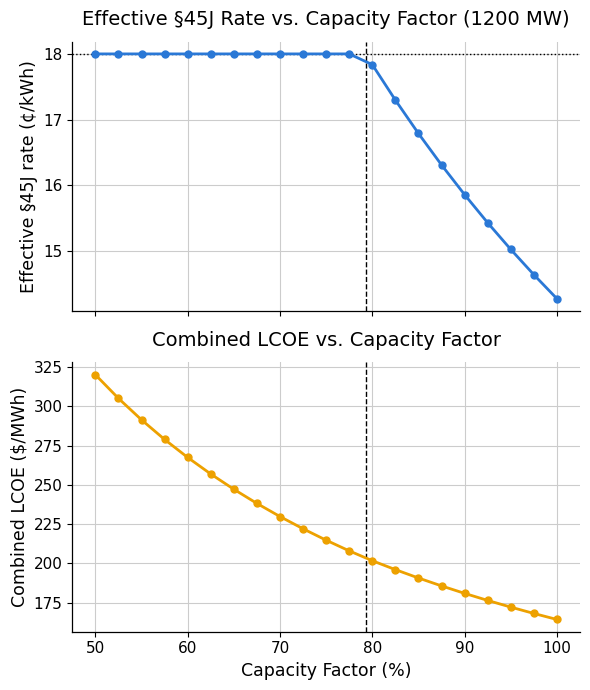

In [3]:
ink = "#000000"
grid_color = "#cccccc"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.0, 7.0), sharex=True)

for ax in (ax1, ax2):
    ax.tick_params(colors=ink, labelsize=11)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(ink)
    ax.spines["left"].set_color(ink)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.spines["left"].set_linewidth(0.9)
    ax.grid(color=grid_color, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

ax1.plot(df_derate["capacity_factor"] * 100, df_derate["effective_45j_rate"] * 1000,
         color="#2a78d6", linewidth=2.0, marker="o", ms=5, zorder=3)
ax1.axhline(18.0, color=ink, linewidth=1.0, linestyle=":", zorder=2)
ax1.axvline(CF_THRESHOLD * 100, color=ink, linewidth=1.0, linestyle="--", zorder=2)
ax1.set_ylabel("Effective §45J rate (¢/kWh)", fontsize=12.5, color=ink)
ax1.set_title("Effective §45J Rate vs. Capacity Factor (1200 MW)", fontsize=14, color=ink, pad=12)

ax2.plot(df_derate["capacity_factor"] * 100, df_derate["lcoe_mwh"],
         color="#eda100", linewidth=2.0, marker="o", ms=5, zorder=3)
ax2.axvline(CF_THRESHOLD * 100, color=ink, linewidth=1.0, linestyle="--", zorder=2)
ax2.set_xlabel("Capacity Factor (%)", fontsize=12.5, color=ink)
ax2.set_ylabel("Combined LCOE ($/MWh)", fontsize=12.5, color=ink)
ax2.set_title("Combined LCOE vs. Capacity Factor", fontsize=14, color=ink, pad=12)

fig.tight_layout()
out_path = EXAMPLE_DIR / "45j_derate_analysis.pdf"
fig.savefig(out_path, bbox_inches="tight", pad_inches=0.03, transparent=True)
print(f"Saved: {out_path.resolve()}")
plt.show()


## Conclusion

**Yes, derating below CF≈ 79.3% does capture the full uncapped \$0.018/kWh
§45J rate** — confirmed directly above: every capacity factor from 50% to
77.5% gets exactly \$0.01800/kWh, while every capacity factor from 80% up
gets a progressively smaller capped rate, bottoming out at \$0.01427/kWh at
full output. The threshold lands almost exactly where the closed-form
math predicts (CF∗=79.27%).

**But no, this does not help LCOE — it makes it dramatically worse.**
Combined LCOE falls monotonically as capacity factor rises across the
*entire* swept range, with no local minimum near the cap threshold: LCOE
is \$315.29/MWh at CF=50% and falls all the way to \$162.01/MWh at CF=100%,
nearly a 2x difference. There is no capacity factor in this range where
derating improves LCOE relative to running at full output.

The reason is straightforward: §45J's dollar credit is capped at a fixed
annual amount regardless of capacity factor (once above the ~79% threshold,
it stays flat at exactly \$150M/year for this 1200~MW unit) — so nothing is
gained by running above the threshold *or* lost by running below it, credit
-wise, until the rate itself starts declining. But CapEx (\$9300/kW, this
unit's single largest cost component) is fixed by rated capacity, not by
how much energy is actually delivered — so any reduction in capacity factor
divides that same fixed cost over strictly less annual energy, driving LCOE
up. That capital-spreading penalty is far larger than any benefit from
capturing a better per-kWh credit rate: going from CF=100% (capped rate,
\$0.01427/kWh) to CF=77.5% (full nominal rate, \$0.01800/kWh) improves the
credit by only $0.0037/kWh, while cutting annual output by 22.5% — a bad
trade. §45J's cap, in other words, is not worth deliberately engineering
around: the plant should always run at the highest capacity factor it can
sustain, and simply accept whatever capped (or uncapped) §45J rate that
capacity factor happens to produce.
